In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report

In [2]:
data = pd.read_csv('creditcard.csv')

In [3]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
fraud_trans = data[data['Class']==1]
norm_trans = data[data['Class']==0]

In [6]:
data.shape

(284807, 31)

In [7]:
y = data['Class']
X = data.drop(columns = ['Class'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
print(X_train.shape, X_test.shape)

(199364, 30) (85443, 30)


In [9]:
model = IsolationForest(contamination = 0.001,  random_state=42, verbose = 1)
model.fit(X_train)

y_train_pred = model.predict(X_train)
y_train_pred[y_train_pred == 1] = 0
y_train_pred[y_train_pred == -1] = 1

y_pred = model.predict(X_test)
y_pred[y_pred == 1] = 0
y_pred[y_pred == -1] = 1

test_accuracy = accuracy_score(y_pred, y_test)
print(f"Test set accuracy: {test_accuracy:.4f}")

train_accuracy = accuracy_score(y_train_pred, y_train)
print(f"Train set accuracy: {train_accuracy:.4f}")

anomaly_score = model.decision_function(X_train)
cm = confusion_matrix(y_test, y_pred)
print("Precision score is", precision_score(y_test, y_pred))
print("Recall score is", recall_score(y_test, y_pred))
print("F1 Score is", f1_score(y_test, y_pred))

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.4s finished


Test set accuracy: 0.9982
Train set accuracy: 0.9979


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.6s


Precision score is 0.3875
Recall score is 0.22794117647058823
F1 Score is 0.28703703703703703


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.3s finished


In [10]:
contamination_list = []
precision_list = []
recall_list = []
f1_score_list = []
for contam in np.linspace(0.001, 0.005, 10):
    model = IsolationForest(max_samples = len(X_train), contamination = contam,  random_state=42, verbose = 1)
    model.fit(X_train)
    
    y_train_pred = model.predict(X_train)
    y_train_pred[y_train_pred == 1] = 0
    y_train_pred[y_train_pred == -1] = 1
    
    y_pred = model.predict(X_test)
    y_pred[y_pred == 1] = 0
    y_pred[y_pred == -1] = 1
    
    test_accuracy = accuracy_score(y_pred, y_test)
    print(f"Test set accuracy: {test_accuracy:.4f}")
    
    train_accuracy = accuracy_score(y_train_pred, y_train)
    print(f"Train set accuracy: {train_accuracy:.4f}")
    
    
    cm = confusion_matrix(y_test, y_pred)
    contamination_list.append(contam)
    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_score_list.append(f1_score(y_test, y_pred))
    # print("Precision score is", precision_score(y_test, y_pred,average='micro'))
    # print("Recall score is", recall_score(y_test, y_pred, average='micro'))
    # print("F1 Score is", f1_score(y_test, y_pred, average='micro'))

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    6.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.8s finished


Test set accuracy: 0.9984
Train set accuracy: 0.9980


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    6.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.8s finished


Test set accuracy: 0.9981
Train set accuracy: 0.9977


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    6.9s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.9s finished


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    6.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.8s finished


Test set accuracy: 0.9958
Train set accuracy: 0.9956


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    5.9s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s


Test set accuracy: 0.9955
Train set accuracy: 0.9953


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.8s finished


In [11]:
output = pd.DataFrame({'contamination': contamination_list, 'precision': precision_list, 'recall': recall_list, 'f1_score': f1_score_list})

In [12]:
output

,contamination,precision,recall,f1_score
0,0.001000,0.481928,0.294118,0.365297
1,0.001444,0.393162,0.338235,0.363636
2,0.001889,0.333333,0.375000,0.352941
3,0.002333,0.324022,0.426471,0.368254
4,0.002778,0.310185,0.492647,0.380682
5,0.003222,0.270992,0.522059,0.356784
6,0.003667,0.252560,0.544118,0.344988
7,0.004111,0.222892,0.544118,0.316239
8,0.004556,0.201613,0.551471,0.295276
9,0.005000,0.191646,0.573529,0.287293


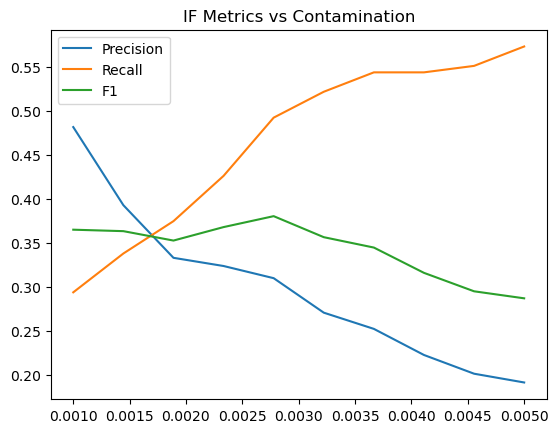

In [13]:
plt.plot(output['contamination'], output['precision'], label='Precision')
plt.plot(output['contamination'], output['recall'], label='Recall')
plt.plot(output['contamination'], output['f1_score'], label='F1')
plt.legend()
plt.title('IF Metrics vs Contamination')
plt.show()

In [ ]:
len(fraud_trans)/float(len(norm_trans))

In [14]:
#Q2) Apply LOF — compare which transactions each method flags
sc = StandardScaler()
X_train['Amount'] = sc.fit_transform(X_train[['Amount']])
X_test['Amount'] = sc.transform(X_test[['Amount']])

model = LocalOutlierFactor(n_neighbors=20, algorithm='auto', leaf_size=30, metric='minkowski', p=2, metric_params=None, contamination=0.001)
#model.fit(X_train)

lof_y_train_pred = model.fit_predict(X_train)
lof_y_train_pred[lof_y_train_pred == 1] = 0
lof_y_train_pred[lof_y_train_pred == -1] = 1

# lof_y_pred = model.predict(X_test)
# lof_y_pred[lof_y_pred == 1] = 0
# lof_y_pred[lof_y_pred == -1] = 1

# test_accuracy = accuracy_score(lof_y_pred, y_test)
# print(f"Test set accuracy: {test_accuracy:.4f}")

train_accuracy = accuracy_score(lof_y_train_pred, y_train)
print(f"Train set accuracy: {train_accuracy:.4f}")

lof_anomaly_score = model.negative_outlier_factor_
cm = confusion_matrix(y_train, lof_y_train_pred)
print("Precision score is", precision_score(y_train, lof_y_train_pred))
print("Recall score is", recall_score(y_train,lof_y_train_pred))
print("F1 Score is", f1_score(y_train, lof_y_train_pred))

Train set accuracy: 0.9974
Precision score is 0.11
Recall score is 0.06179775280898876
F1 Score is 0.07913669064748201


In [16]:
print(classification_report(y_train,lof_y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199008
           1       0.11      0.06      0.08       356

    accuracy                           1.00    199364
   macro avg       0.55      0.53      0.54    199364
weighted avg       1.00      1.00      1.00    199364



In [17]:
result = pd.DataFrame({'actual': y_train, 'prediction_IF': y_train_pred, 'prediction_lof': lof_y_train_pred, 'anomaly_score_IF': anomaly_score, 'anomaly_score_lof' : lof_anomaly_score})

In [18]:
result.shape, X_train.shape

((199364, 5), (199364, 30))

In [19]:
# X_train.reset_index(drop=True, inplace=True)
# result.reset_index(drop=True, inplace=True)
result = pd.concat([X_train, result], axis = 1)

In [20]:
result[(result['prediction_lof'] == 1) & (result['actual'] == 1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,actual,prediction_IF,prediction_lof,anomaly_score_IF,anomaly_score_lof
43681,41607.0,-18.247513,8.713250,-17.880127,9.249459,-14.541213,-1.911564,-18.014660,5.522162,-9.283925,...,-0.236845,-0.046082,-3.011473,-1.022147,-0.134854,1,1,1,-0.009437,-4.723056
42473,41116.0,-3.600544,4.519047,-6.340884,6.214767,-5.829558,-2.478095,-9.938412,2.830086,-5.659162,...,0.398142,0.008277,2.053524,0.835749,-0.328952,1,1,1,0.017426,-4.796598
42958,41313.0,-13.897206,6.344280,-14.281666,5.581009,-12.887133,-3.146176,-15.450467,9.060281,-5.486121,...,0.075456,-0.453840,-1.508968,-0.686836,-0.304960,1,1,1,-0.033255,-4.684940
102446,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,0.263203,-0.108877,1.269566,0.939407,-0.339748,1,1,1,-0.009715,-5.629424
8296,11080.0,-2.125490,5.973556,-11.034727,9.007147,-1.689451,-2.854415,-7.810441,2.030870,-5.902828,...,1.701796,0.690806,2.119749,1.108933,-0.339748,1,1,1,-0.002576,-4.000813
42590,41164.0,-5.932778,4.571743,-9.427247,6.577056,-6.115218,-3.661798,-10.894079,3.709210,-5.859524,...,-0.077884,0.565493,1.792012,0.371007,-0.323109,1,1,1,-0.004703,-4.100170
44223,41851.0,-19.139733,9.286847,-20.134992,7.818673,-15.652208,-1.668348,-21.340478,0.641900,-8.550110,...,-0.948454,0.121796,-3.381843,-1.256524,0.197736,1,1,1,-0.015375,-5.715088
102444,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,0.263203,-0.108877,1.269566,0.939407,-0.339748,1,1,1,-0.009715,-5.629424
42936,41305.0,-12.980943,6.720508,-13.455636,8.698610,-11.479552,-2.681519,-14.019291,8.218191,-7.930900,...,0.226598,-0.006168,-1.185696,-0.747361,-0.112681,1,1,1,-0.024119,-4.338027
43204,41413.0,-15.140450,7.378042,-16.356367,9.194935,-13.466163,-2.958431,-16.165539,10.075254,-7.901821,...,-0.194542,0.145964,-2.458680,-1.189888,0.068686,1,1,1,-0.045366,-5.502270


In [22]:
result[(result['prediction_IF'] == 1) & (result['actual'] == 1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,actual,prediction_IF,prediction_lof,anomaly_score_IF,anomaly_score_lof
42700,41204.0,-8.440284,6.147653,-11.683706,6.702780,-8.155839,-3.716264,-12.407313,5.626571,-6.232161,...,-0.018788,0.522722,0.792691,0.067790,-0.226524,1,1,0,-0.005239,-3.852716
6899,8878.0,-2.661802,5.856393,-7.653616,6.379742,-0.060712,-3.131550,-3.103570,1.778492,-3.831154,...,1.007934,0.413196,0.280284,0.303937,-0.339748,1,1,0,0.055881,-1.005299
42009,40919.0,-2.740483,3.658095,-4.110636,5.340242,-2.666775,-0.092782,-4.388699,-0.280133,-2.821895,...,-0.403956,0.277895,0.830062,0.218690,0.091052,1,1,0,0.071829,-2.141763
235634,148476.0,-1.125092,3.682876,-6.556168,4.016731,-0.425571,-2.031210,-2.650137,1.131249,-2.946890,...,-1.174469,-0.087832,0.718790,0.676216,-0.340677,1,1,0,0.066736,-1.779416
238222,149582.0,-4.280584,1.421100,-3.908229,2.942946,-0.076205,-2.002526,-2.874155,-0.856005,0.963674,...,0.056276,-1.149923,-1.809886,0.723051,-0.339361,1,1,0,0.085150,-2.408615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153885,100501.0,-6.985267,5.151094,-4.599338,4.534479,0.849054,-0.210701,-4.425230,-5.134525,0.069321,...,0.569358,0.145971,0.300193,1.779364,-0.340677,1,1,0,0.059943,-0.989006
42674,41194.0,-7.896886,5.381020,-8.451162,7.963928,-7.862419,-2.376820,-11.949723,5.051356,-6.912076,...,0.361887,0.444577,1.101923,0.205958,-0.337736,1,1,1,-0.008079,-4.129027
33276,37167.0,-7.923891,-5.198360,-3.000024,4.420666,2.272194,-3.394483,-5.283435,0.131619,0.658176,...,-1.167660,0.520508,1.937421,-1.552593,-0.295983,1,1,0,0.026282,-1.711361
154697,102625.0,-4.221221,2.871121,-5.888716,6.890952,-3.404894,-1.154394,-7.739928,2.851363,-2.507569,...,-1.829169,-0.072429,0.136734,-0.599848,-0.314247,1,1,0,0.032406,-0.958007


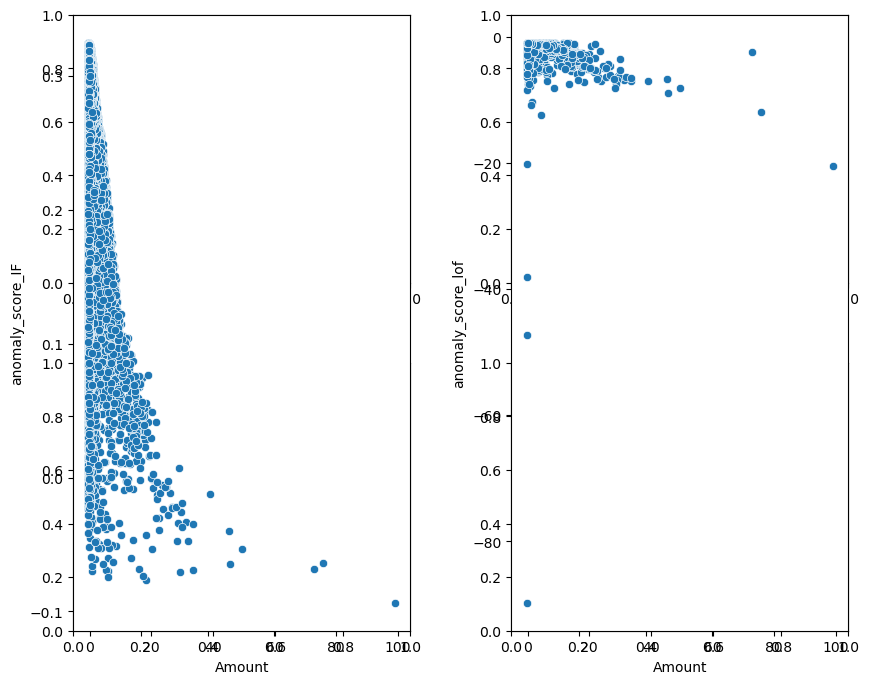

In [23]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
fig.subplots_adjust(wspace=0.3)
fig.subplots_adjust(hspace=0.3)
fig.set_size_inches(10, 8)

plt.subplot(1,2,1)
sns.scatterplot(data=result,x="Amount",y="anomaly_score_IF")
plt.subplot(1,2,2)
sns.scatterplot(data=result,x="Amount",y="anomaly_score_lof")
plt.show()

In [ ]:
#LOF predicted 22 correctly out of 492 fraud cases, whereas isolation forest predicted 208 correctly out of 492 fraud cases.